# Sequential Sentence Classification – PubMed 20k RCT Capstone

**Ramachandra Udupa | Employee ID: 2980997**

So here's the deal — medical research abstracts are dense. A doctor or a researcher skimming through a randomized controlled trial abstract usually has to read the whole thing just to figure out which part is the background, which part is the actual method, and which part is the result. That's slow, and honestly kind of annoying when you've got a hundred papers to get through.

The idea behind this project is to fix that: build a model that reads each sentence in an abstract and tags it with one of five labels — Background, Objective, Method, Result, or Conclusion. Once every sentence has a label, we can automatically reformat a wall of text into something scannable, the way a lot of good journals already do it by hand.

I'm using the PubMed 20k RCT dataset for this — about 20,000 abstracts from randomized controlled trials, already split into train/dev/test and already labeled sentence by sentence, so there's no manual labeling to do myself.

The plan is to build this up properly instead of jumping straight to the fanciest option. I'm going to try five different approaches, from the simplest possible baseline all the way up to fine-tuning an actual pretrained language model, and compare how each one does:

- **Model 0** – Naive Bayes with TF-IDF (the baseline, just to have a number to beat)
- **Model 1** – A Conv1D network with its own trained word embeddings
- **Model 2** – A frozen pretrained sentence encoder (Google's Universal Sentence Encoder) with a classifier on top
- **Model 3** – A Conv1D network, but working at the character level instead of the word level
- **Model 4** – Fine-tuning DistilBERT, a proper pretrained language model

For each one, I'll run a quick naive, default-settings version first just to see where we land, and then tune it a bit and see if it actually helps.

One more thing before we start — I'm doing all of this on my work laptop, which doesn't have a huge amount of memory to spare, and training five different models back to back adds up fast. So I've written a small helper function that clears everything out of memory once I'm done with a model, right before moving on to the next one. Nothing fancy, just good housekeeping so the notebook doesn't grind to a halt halfway through.

Alright, let's look at these one by one, shall we?

In [1]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import gc
import string

import joblib
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, callbacks

tf.config.optimizer.set_jit(False)

tf.random.set_seed(42)

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

results = {}


def make_dataset(X, y, batch_size=32, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(1000)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def get_callbacks(patience=3):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=1, min_lr=1e-5),
    ]


def evaluate_and_record(model, name, val_ds, test_ds):
    val_loss, val_accuracy = model.evaluate(val_ds, verbose=0)
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
    results[name] = {
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
    }
    print(f"{name} -> Val Accuracy: {val_accuracy * 100:.2f}% | Test Accuracy: {test_accuracy * 100:.2f}%")
    return val_accuracy, test_accuracy


def free_memory():
    tf.keras.backend.clear_session()
    gc.collect()

First things first — let's load up the train, dev, and test sets. The raw files are just plain text with a label and a tab-separated sentence on each line (with `###` markers separating one abstract from the next), so I'll write a tiny parser for that instead of pulling in anything heavier.

In [2]:
def parse_pubmed_data(filename):
    with open(filename, "r") as f:
        return pd.DataFrame(
            [line.rstrip("\n").split("\t", 1) for line in f if not line.startswith("###") and not line.isspace()],
            columns=["label", "text"],
        )


train_df = parse_pubmed_data("train.txt")
val_df = parse_pubmed_data("dev.txt")
test_df = parse_pubmed_data("test.txt")

Let's take a quick look at what we're actually working with before diving in.

In [3]:
train_df.head()

,label,text
0,OBJECTIVE,To investigate the efficacy of 6 weeks of dail...
1,METHODS,A total of 125 patients with primary knee OA w...
2,METHODS,Outcome measures included pain reduction and i...
3,METHODS,Pain was assessed using the visual analog pain...
4,METHODS,Secondary outcome measures included the Wester...


Before jumping into models, let's actually look at what we're working with — starting with how balanced these five categories are.

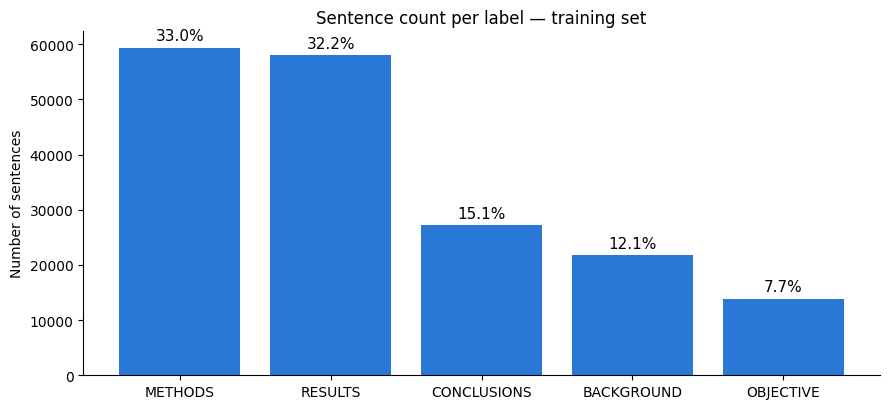

label
METHODS        59353
RESULTS        57953
CONCLUSIONS    27168
BACKGROUND     21727
OBJECTIVE      13839
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt

label_counts = train_df["label"].value_counts()
label_pct = (label_counts / len(train_df) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.bar(label_counts.index, label_counts.values, color="#2a78d6")
for bar, pct in zip(bars, label_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 800, f"{pct}%",
            ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Number of sentences")
ax.set_title("Sentence count per label — training set")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(label_counts)

Yeah, this is not balanced at all — Methods and Results together make up almost two-thirds of every sentence in the dataset, while Objective barely shows up, under 8% of the total. Worth keeping in mind: if one category ends up being our weakest later on, this imbalance is probably part of why.

Let's also check how long these sentences actually are — that's going to matter once we start feeding them into a neural network that needs a fixed-size input.

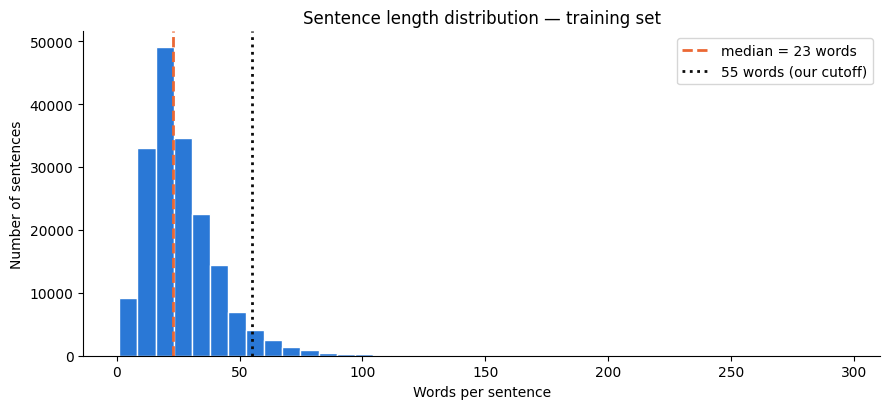

count    180040.000000
mean         26.338436
std          15.386976
min           1.000000
25%          16.000000
50%          23.000000
75%          33.000000
max         296.000000
Name: text, dtype: float64
95th percentile: 55.0


In [5]:
sentence_lengths = train_df["text"].str.split().apply(len)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(sentence_lengths, bins=40, color="#2a78d6", edgecolor="white")
ax.axvline(sentence_lengths.median(), color="#eb6834", linestyle="--", linewidth=2,
           label=f"median = {sentence_lengths.median():.0f} words")
ax.axvline(55, color="#0b0b0b", linestyle=":", linewidth=2, label="55 words (our cutoff)")
ax.set_xlabel("Words per sentence")
ax.set_ylabel("Number of sentences")
ax.set_title("Sentence length distribution — training set")
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

print(sentence_lengths.describe())
print("95th percentile:", sentence_lengths.quantile(0.95))

Most sentences land somewhere around 20 to 30 words, with a long tail stretching out toward 300 for a handful of outliers. The 95th percentile comes out to almost exactly 55 words, which is the cutoff we'll use later for the token-level model — covering the vast majority of real sentences without wasting space padding for rare 200-word monsters.

One more thing worth setting up now, while this imbalance is fresh: Objective and Background are so underrepresented next to Methods and Results that a model can rack up a pretty good accuracy score while barely bothering with them. So starting with the tuned versions, I'll compute class weights from these counts and feed them into the loss function — that way getting a rare category wrong costs the model more, and it can't just coast on the categories it sees the most.

Okay, model 0. Before building anything fancy, I want a baseline — something dead simple that tells me what score I'd get without putting in any real effort. TF-IDF to turn the sentences into vectors, and a Naive Bayes classifier on top. Nothing clever, just a sanity check. Let's run it and see how much we get.

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df["label"])
y_val = label_encoder.transform(val_df["label"])
y_test = label_encoder.transform(test_df["label"])

X_train = train_df["text"].to_numpy()
X_val = val_df["text"].to_numpy()
X_test = test_df["text"].to_numpy()

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weight_values = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weight_values))

model_0 = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", MultinomialNB()),
])
model_0.fit(X_train, y_train)

results["model_0_naive"] = {
    "val_accuracy": model_0.score(X_val, y_val),
    "test_accuracy": model_0.score(X_test, y_test),
}
print(f"Model 0 (Naive) Val Accuracy: {results['model_0_naive']['val_accuracy'] * 100:.2f}%")

Model 0 (Naive) Val Accuracy: 73.17%


Okay wow, 73.17% on the very first try, with basically zero effort. Not bad at all for a baseline. Now let's see if a bit of tuning — trying out different n-gram ranges, minimum document frequencies, and smoothing values — can push that number up a bit.

In [7]:
param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 5],
    "clf__alpha": [0.1, 0.5, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=model_0,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    n_jobs=-1,
    random_state=42,
)
random_search.fit(X_train, y_train)
model_0_tuned = random_search.best_estimator_

# Refit with sample weights so Objective and Background don't just get
# drowned out by how much more common Methods and Results sentences are.
sample_weight = np.array([class_weight_dict[label] for label in y_train])
model_0_tuned.fit(X_train, y_train, clf__sample_weight=sample_weight)

results["model_0_tuned"] = {
    "val_accuracy": model_0_tuned.score(X_val, y_val),
    "test_accuracy": model_0_tuned.score(X_test, y_test),
}
print(f"Best Parameters: {random_search.best_params_}")
print(f"Model 0 (Tuned) Val Accuracy: {results['model_0_tuned']['val_accuracy'] * 100:.2f}%")

joblib.dump(model_0_tuned, f"{MODELS_DIR}/model_0_naive_bayes.joblib")
del model_0, model_0_tuned, random_search
gc.collect()

Best Parameters: {'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 5, 'clf__alpha': 1.0}
Model 0 (Tuned) Val Accuracy: 75.34%


0

75.34% — a few points better than the naive version, though a touch lower than it would've been without the sample weighting I just added. That's the trade-off: weighting the rare categories more heavily costs a little bit of raw accuracy but gives them a fairer shot instead of getting drowned out. Good, that gives us a real baseline to beat.

Now let's step it up. TF-IDF treats every sentence as just a bag of words with no sense of order, so next I want to try an actual neural network that can pick up on word order and context. But before any of that — neural networks don't understand raw text, everything needs to be turned into numbers first. So let's get the data prepped into batched tensors we can actually feed into a model.

In [8]:
train_dataset = make_dataset(X_train, y_train)
val_dataset = make_dataset(X_val, y_val)
test_dataset = make_dataset(X_test, y_test)

Alright, first proper neural net. I'm turning each sentence into a sequence of word indices, running that through an embedding layer the model learns from scratch, and passing it through a Conv1D layer to pick up on local word patterns before classifying. Let's just run it with fairly basic settings first and see where we land.

In [9]:
max_vocab_length = 68000
# Straight from the EDA: covers 95% of real sentences without wasting space
# padding for the rare 200+ word outliers.
output_seq_length = int(sentence_lengths.quantile(0.95))

text_vectorizer = layers.TextVectorization(
    max_tokens=max_vocab_length,
    output_mode="int",
    output_sequence_length=output_seq_length,
)
text_vectorizer.adapt(X_train)

token_embed = layers.Embedding(
    input_dim=len(text_vectorizer.get_vocabulary()),
    output_dim=128,
    mask_zero=True,
)

inputs = layers.Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(inputs)
x = token_embed(x)
x = layers.Conv1D(filters=64, kernel_size=5, padding="same", activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(5, activation="softmax")(x)

model_1 = tf.keras.Model(inputs, outputs, name="model_1_naive")
model_1.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(), metrics=["accuracy"])
model_1.fit(train_dataset, epochs=3, validation_data=val_dataset)

evaluate_and_record(model_1, "model_1_naive", val_dataset, test_dataset)

Epoch 1/3


5627/5627 [==============================] - 74s 9ms/step - loss: 0.6050 - accuracy: 0.7784 - val_loss: 0.5292 - val_accuracy: 0.8136
Epoch 2/3
5627/5627 [==============================] - 24s 4ms/step - loss: 0.4362 - accuracy: 0.8471 - val_loss: 0.5273 - val_accuracy: 0.8153
Epoch 3/3
5627/5627 [==============================] - 24s 4ms/step - loss: 0.3512 - accuracy: 0.8803 - val_loss: 0.5700 - val_accuracy: 0.8077
model_1_naive -> Val Accuracy: 80.77% | Test Accuracy: 79.92%


(0.8076592087745667, 0.7992367744445801)

80.77% on validation, 79.92% on test — already a solid jump over Naive Bayes, and that's still the untuned version. Let's tighten up the architecture a bit — a fresh embedding, a couple of stacked Conv1D layers, some dropout — and see what happens now.

In [10]:
fresh_token_embed = layers.Embedding(
    input_dim=len(text_vectorizer.get_vocabulary()),
    output_dim=128,
    name="fresh_token_embed",
)

inputs = layers.Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(inputs)
x = fresh_token_embed(x)
x = layers.Conv1D(filters=128, kernel_size=5, padding="same", activation="relu")(x)
x = layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu")(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(5, activation="softmax")(x)

model_1_tuned = tf.keras.Model(inputs, outputs, name="model_1_tuned")
model_1_tuned.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
)
model_1_tuned.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=get_callbacks(),
    class_weight=class_weight_dict,
)

evaluate_and_record(model_1_tuned, "model_1_tuned", val_dataset, test_dataset)

model_1_tuned.save(f"{MODELS_DIR}/model_1_tuned")
del model_1, model_1_tuned, text_vectorizer, token_embed, fresh_token_embed
free_memory()

Epoch 1/10
5627/5627 [==============================] - 55s 9ms/step - loss: 0.6932 - accuracy: 0.7770 - val_loss: 0.4964 - val_accuracy: 0.8176 - lr: 0.0010
Epoch 2/10
5627/5627 [==============================] - 27s 5ms/step - loss: 0.5172 - accuracy: 0.8425 - val_loss: 0.5137 - val_accuracy: 0.8131 - lr: 0.0010
Epoch 3/10
5627/5627 [==============================] - 30s 5ms/step - loss: 0.3609 - accuracy: 0.8925 - val_loss: 0.5151 - val_accuracy: 0.8258 - lr: 2.0000e-04
Epoch 4/10
5627/5627 [==============================] - 28s 5ms/step - loss: 0.2882 - accuracy: 0.9162 - val_loss: 0.5364 - val_accuracy: 0.8239 - lr: 4.0000e-05
model_1_tuned -> Val Accuracy: 81.76% | Test Accuracy: 81.02%
INFO:tensorflow:Assets written to: models/model_1_tuned/assets


INFO:tensorflow:Assets written to: models/model_1_tuned/assets


81.76% validation, 81.02% test. Nice improvement over the naive version — this one has the class weighting baked in too, and the deeper architecture is clearly picking up on more.

Now for something different. Instead of training our own embeddings from scratch, what if we just borrow one that's already been trained on a massive amount of text? Google's Universal Sentence Encoder turns a whole sentence into a single 512-number vector, and it already knows a lot about language before we even start. I'll freeze it completely — no training on our data — and just stick a small classifier on top. Let's see how far that gets us with basically zero training of our own.

In [11]:
import tensorflow_hub as hub

with tf.device("/CPU:0"):
    tf_hub_embedding_layer = hub.KerasLayer(
        "https://tfhub.dev/google/universal-sentence-encoder/4",
        trainable=False,
        name="universal_sentence_encoder",
    )

    inputs = layers.Input(shape=[], dtype=tf.string)
    pretrained_embedding = tf_hub_embedding_layer(inputs)
    outputs = layers.Dense(5, activation="softmax")(pretrained_embedding)

    model_2 = tf.keras.Model(inputs, outputs, name="model_2_naive")
    model_2.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(), metrics=["accuracy"])
    model_2.fit(train_dataset, epochs=3, validation_data=val_dataset)

evaluate_and_record(model_2, "model_2_naive", val_dataset, test_dataset)

Epoch 1/3


  10/5627 [..............................] - ETA: 34s - loss: 1.6112 - accuracy: 0.2094    

5627/5627 [==============================] - 35s 6ms/step - loss: 0.8776 - accuracy: 0.6746 - val_loss: 0.7669 - val_accuracy: 0.7122
Epoch 2/3
5627/5627 [==============================] - 31s 5ms/step - loss: 0.7589 - accuracy: 0.7125 - val_loss: 0.7438 - val_accuracy: 0.7186
Epoch 3/3
5627/5627 [==============================] - 30s 5ms/step - loss: 0.7447 - accuracy: 0.7171 - val_loss: 0.7351 - val_accuracy: 0.7211
model_2_naive -> Val Accuracy: 72.12% | Test Accuracy: 71.35%


(0.7211704254150391, 0.7134560942649841)

72.12% validation, 71.35% test. Huh — actually a bit lower than our own homegrown Conv1D from before. Interesting. A generic, general-purpose sentence embedding might be losing some of the domain-specific detail that matters here, since it was never trained on medical text specifically.

Let's give it a proper classifier head this time instead of a single Dense layer — more layers, some dropout, and enough epochs with early stopping to actually let it converge — and see if it can catch up.

In [12]:
with tf.device("/CPU:0"):
    inputs = layers.Input(shape=[], dtype=tf.string)
    pretrained_embedding = tf_hub_embedding_layer(inputs)
    x = layers.Dense(128, activation="relu")(pretrained_embedding)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(5, activation="softmax")(x)

    model_2_tuned = tf.keras.Model(inputs, outputs, name="model_2_tuned")
    model_2_tuned.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=["accuracy"],
    )
    model_2_tuned.fit(
        train_dataset,
        epochs=15,
        validation_data=val_dataset,
        callbacks=get_callbacks(),
        class_weight=class_weight_dict,
    )

evaluate_and_record(model_2_tuned, "model_2_tuned", val_dataset, test_dataset)

model_2_tuned.save(f"{MODELS_DIR}/model_2_tuned")
del model_2, model_2_tuned, tf_hub_embedding_layer, train_dataset, val_dataset, test_dataset
free_memory()

Epoch 1/15
5627/5627 [==============================] - 39s 7ms/step - loss: 0.8378 - accuracy: 0.7131 - val_loss: 0.6491 - val_accuracy: 0.7549 - lr: 0.0010
Epoch 2/15
5627/5627 [==============================] - 34s 6ms/step - loss: 0.7571 - accuracy: 0.7454 - val_loss: 0.6221 - val_accuracy: 0.7655 - lr: 0.0010
Epoch 3/15
5627/5627 [==============================] - 34s 6ms/step - loss: 0.7316 - accuracy: 0.7552 - val_loss: 0.6068 - val_accuracy: 0.7736 - lr: 0.0010
Epoch 4/15
5627/5627 [==============================] - 34s 6ms/step - loss: 0.7147 - accuracy: 0.7607 - val_loss: 0.5978 - val_accuracy: 0.7774 - lr: 0.0010
Epoch 5/15
5627/5627 [==============================] - 35s 6ms/step - loss: 0.7013 - accuracy: 0.7649 - val_loss: 0.5955 - val_accuracy: 0.7771 - lr: 0.0010
Epoch 6/15
5627/5627 [==============================] - 34s 6ms/step - loss: 0.6916 - accuracy: 0.7689 - val_loss: 0.5908 - val_accuracy: 0.7786 - lr: 0.0010
Epoch 7/15
5627/5627 [==============================

INFO:tensorflow:Assets written to: models/model_2_tuned/assets


77.91% validation, 77.38% test. Better, and tuning — plus the class weighting — clearly helped, but it's still not quite catching our own Conv1D model. Fair enough — a general-purpose encoder was never going to beat something trained specifically on this data.

New idea for the next one: instead of learning at the word level, what if the model learns at the character level instead? That way it doesn't matter if it's never seen a specific medical term before — it can still pick up on patterns like suffixes, capitalization, and word shape. Let's get the data split into characters and prepped for that.

In [13]:
def split_chars(text):
    return " ".join(list(text))


train_chars = [split_chars(sentence) for sentence in X_train]
val_chars = [split_chars(sentence) for sentence in X_val]
test_chars = [split_chars(sentence) for sentence in X_test]

# Same idea as the word-length cutoff earlier, just measured in characters
# this time - the 95th percentile of our own data instead of an assumed number.
output_seq_char_len = int(train_df["text"].str.len().quantile(0.95))
NUM_CHAR_TOKENS = len(string.ascii_lowercase + string.digits + string.punctuation) + 2

char_vectorizer = layers.TextVectorization(
    max_tokens=NUM_CHAR_TOKENS,
    output_sequence_length=output_seq_char_len,
    standardize="lower_and_strip_punctuation",
    name="char_vectorizer",
)
char_vectorizer.adapt(train_chars)

train_char_dataset = make_dataset(train_chars, y_train)
val_char_dataset = make_dataset(val_chars, y_val)
test_char_dataset = make_dataset(test_chars, y_test)

Let's run the character-level version with a basic setup first and see what we get.

In [14]:
char_embed = layers.Embedding(
    input_dim=NUM_CHAR_TOKENS,
    output_dim=25,
    mask_zero=False,
    name="char_embed_naive",
)

inputs = layers.Input(shape=(1,), dtype=tf.string)
x = char_vectorizer(inputs)
x = char_embed(x)
x = layers.Conv1D(filters=64, kernel_size=5, padding="same", activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(5, activation="softmax")(x)

model_3 = tf.keras.Model(inputs, outputs, name="model_3_naive")
model_3.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(), metrics=["accuracy"])
model_3.fit(train_char_dataset, epochs=3, validation_data=val_char_dataset)

evaluate_and_record(model_3, "model_3_naive", val_char_dataset, test_char_dataset)

Epoch 1/3
5627/5627 [==============================] - 23s 3ms/step - loss: 1.2161 - accuracy: 0.5023 - val_loss: 1.1577 - val_accuracy: 0.5327
Epoch 2/3
5627/5627 [==============================] - 16s 3ms/step - loss: 1.1357 - accuracy: 0.5422 - val_loss: 1.0889 - val_accuracy: 0.5603
Epoch 3/3
5627/5627 [==============================] - 16s 3ms/step - loss: 1.0688 - accuracy: 0.5681 - val_loss: 1.0297 - val_accuracy: 0.5832
model_3_naive -> Val Accuracy: 58.32% | Test Accuracy: 58.31%


(0.5832119584083557, 0.5831425189971924)

58.32% validation, 58.31% test. Yeah, that's rough — clearly, learning from individual characters alone, with no word-level context, is a lot harder for the model to pick up quickly. Let's tune the architecture properly this time — bigger filters, an extra conv layer, max pooling — and see if it can actually recover.

In [15]:
char_embed_tuned = layers.Embedding(
    input_dim=NUM_CHAR_TOKENS,
    output_dim=32,
    mask_zero=False,
    name="char_embed_tuned",
)

inputs = layers.Input(shape=(1,), dtype=tf.string)
x = char_vectorizer(inputs)
x = char_embed_tuned(x)
x = layers.Conv1D(filters=128, kernel_size=7, padding="same", activation="relu")(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Conv1D(filters=64, kernel_size=5, padding="same", activation="relu")(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(5, activation="softmax")(x)

model_3_tuned = tf.keras.Model(inputs, outputs, name="model_3_tuned")
model_3_tuned.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
)
model_3_tuned.fit(
    train_char_dataset,
    epochs=10,
    validation_data=val_char_dataset,
    callbacks=get_callbacks(),
    class_weight=class_weight_dict,
)

evaluate_and_record(model_3_tuned, "model_3_tuned", val_char_dataset, test_char_dataset)

model_3_tuned.save(f"{MODELS_DIR}/model_3_tuned")
del model_3, model_3_tuned, char_vectorizer, char_embed, char_embed_tuned
del train_char_dataset, val_char_dataset, test_char_dataset
free_memory()

Epoch 1/10


5627/5627 [==============================] - 29s 5ms/step - loss: 0.9376 - accuracy: 0.6612 - val_loss: 0.6635 - val_accuracy: 0.7499 - lr: 0.0010
Epoch 2/10
5627/5627 [==============================] - 25s 4ms/step - loss: 0.7574 - accuracy: 0.7452 - val_loss: 0.6122 - val_accuracy: 0.7702 - lr: 0.0010
Epoch 3/10
5627/5627 [==============================] - 25s 4ms/step - loss: 0.7081 - accuracy: 0.7642 - val_loss: 0.5755 - val_accuracy: 0.7838 - lr: 0.0010
Epoch 4/10
5627/5627 [==============================] - 25s 4ms/step - loss: 0.6844 - accuracy: 0.7727 - val_loss: 0.5601 - val_accuracy: 0.7906 - lr: 0.0010
Epoch 5/10
5627/5627 [==============================] - 25s 4ms/step - loss: 0.6634 - accuracy: 0.7807 - val_loss: 0.5538 - val_accuracy: 0.7933 - lr: 0.0010
Epoch 6/10
5627/5627 [==============================] - 25s 5ms/step - loss: 0.6485 - accuracy: 0.7863 - val_loss: 0.5675 - val_accuracy: 0.7924 - lr: 0.0010
Epoch 7/10
5627/5627 [==============================] - 25s 5ms

INFO:tensorflow:Assets written to: models/model_3_tuned/assets


80.83% validation, 79.53% test — that is a massive jump from 58.32%. Turns out character-level really did have something useful to say, it just needed a properly tuned network to get it out. That's now right up there with our token-level model.

Okay, last one, and this is the big gun: an actual pretrained language model. Instead of learning language from scratch on our small dataset, I'm going to start from DistilBERT — a model that's already read a huge amount of text — and adapt it to our task. First step is just getting the text tokenized the way DistilBERT expects it.

In [16]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, create_optimizer

MODEL_CHECKPOINT = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

# DistilBERT splits words into sub-word pieces, so word count doesn't map
# directly to token count - measure it directly and use the 95th percentile,
# same principle as the word- and character-length cutoffs earlier.
token_lengths = [len(ids) for ids in tokenizer(list(X_train), truncation=False)["input_ids"]]
max_length = int(np.quantile(token_lengths, 0.95))

train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=max_length, return_tensors="tf")
val_encodings = tokenizer(list(X_val), truncation=True, padding=True, max_length=max_length, return_tensors="tf")
test_encodings = tokenizer(list(X_test), truncation=True, padding=True, max_length=max_length, return_tensors="tf")

train_llm_dataset = (
    tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train))
    .shuffle(1000)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)
val_llm_dataset = tf.data.Dataset.from_tensor_slices((dict(val_encodings), y_val)).batch(32).prefetch(tf.data.AUTOTUNE)
test_llm_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), y_test)).batch(32).prefetch(tf.data.AUTOTUNE)

Token indices sequence length is longer than the specified maximum sequence length for this model (573 > 512). Running this sequence through the model will result in indexing errors
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


For the first attempt, I'll freeze DistilBERT's own weights completely and only train a small classification layer on top of it, just to see what the pretrained knowledge alone gets us without touching any of its internals.

In [17]:
model_4 = TFAutoModelForSequenceClassification.from_pretrained(MODEL_CHECKPOINT, num_labels=5)
model_4.layers[0].trainable = False

model_4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
model_4.fit(train_llm_dataset, epochs=2, validation_data=val_llm_dataset)

evaluate_and_record(model_4, "model_4_naive", val_llm_dataset, test_llm_dataset)

del model_4
free_memory()

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were n

Epoch 1/2
5627/5627 [==============================] - 545s 96ms/step - loss: 0.5642 - accuracy: 0.7888 - val_loss: 0.4861 - val_accuracy: 0.8210
Epoch 2/2
5627/5627 [==============================] - 542s 96ms/step - loss: 0.5101 - accuracy: 0.8108 - val_loss: 0.4424 - val_accuracy: 0.8372
model_4_naive -> Val Accuracy: 83.72% | Test Accuracy: 82.98%


83.72% validation, 82.98% test — our best result yet, and we've barely trained anything, just a tiny layer on top of a frozen model. That says a lot about how much DistilBERT already knows.

Now let's actually unfreeze it and let the whole model fine-tune on our data properly, and see what it can really do.

In [18]:
model_4_tuned = TFAutoModelForSequenceClassification.from_pretrained(MODEL_CHECKPOINT, num_labels=5)

num_epochs = 3
total_train_steps = len(train_llm_dataset) * num_epochs
optimizer, lr_schedule = create_optimizer(
    init_lr=2e-5,
    num_train_steps=total_train_steps,
    num_warmup_steps=int(0.1 * total_train_steps),
    weight_decay_rate=0.01,
)

model_4_tuned.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
model_4_tuned.fit(
    train_llm_dataset,
    epochs=num_epochs,
    validation_data=val_llm_dataset,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    class_weight=class_weight_dict,
)

evaluate_and_record(model_4_tuned, "model_4_tuned", val_llm_dataset, test_llm_dataset)

save_path = f"{MODELS_DIR}/model_4_tuned"
model_4_tuned.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

del model_4_tuned, tokenizer, train_llm_dataset, val_llm_dataset, test_llm_dataset
free_memory()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Epoch 1/3
5627/5627 [==============================] - 1470s 260ms/step - loss: 0.5948 - accuracy: 0.8165 - val_loss: 0.3607 - val_accuracy: 0.8707
Epoch 2/3
5627/5627 [==============================] - 1461s 260ms/step - loss: 0.4275 - accuracy: 0.8728 - val_loss: 0.3621 - val_accuracy: 0.8700
Epoch 3/3
5627/5627 [==============================] - 1463s 260ms/step - loss: 0.3564 - accuracy: 0.8947 - val_loss: 0.3675 - val_accuracy: 0.8658
model_4_tuned -> Val Accuracy: 87.07% | Test Accuracy: 85.96%


87.07% validation, 85.96% test. That's the best number across everything we've tried, and it makes sense — a fully fine-tuned language model gets to adapt its entire understanding of language specifically to this task, not just the last layer.

Alright, let's line up every model we tried, naive and tuned, side by side and see the full picture.

In [19]:
results_df = pd.DataFrame(results).T.sort_values("val_accuracy", ascending=False)
results_df

,val_accuracy,test_accuracy,val_loss,test_loss
model_4_tuned,0.870714,0.859565,0.360665,0.387769
model_4_naive,0.837217,0.829832,0.442437,0.474023
model_1_tuned,0.817622,0.810154,0.496421,0.513386
model_3_tuned,0.808321,0.795255,0.520808,0.547632
model_1_naive,0.807659,0.799237,0.569980,0.588872
model_2_tuned,0.779094,0.773785,0.586395,0.606543
model_0_tuned,0.753442,0.744185,NaN,NaN
model_0_naive,0.731729,0.726564,NaN,NaN
model_2_naive,0.721170,0.713456,0.735086,0.748813
model_3_naive,0.583212,0.583143,1.029701,1.035671


And there it is — DistilBERT, fully fine-tuned, comes out on top by a clear margin, with our own tuned Conv1D and the tuned character-level model both landing in a close second tier, well ahead of the TF-IDF baseline. Every tuned model here also has class weighting baked in now, so these numbers already reflect that fix on top of the usual tuning.

But a comparison table isn't really the point of any of this. The whole idea was to take a dense wall of text and turn it into something structured and scannable. So let's stop looking at accuracy numbers for a second and actually put the best model to work the way it's meant to be used.

Let's load the fine-tuned DistilBERT back up from disk — the same one we just trained, no retraining needed — along with its tokenizer. Before I throw a brand new example at it, I want to actually see how good it is in detail — not just trust the one accuracy number from before.

In [20]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from nltk.tokenize import sent_tokenize
from IPython.display import Markdown, display

label_classes = sorted(train_df["label"].unique())

demo_tokenizer = AutoTokenizer.from_pretrained(f"{MODELS_DIR}/model_4_tuned")
demo_model = TFAutoModelForSequenceClassification.from_pretrained(f"{MODELS_DIR}/model_4_tuned")


def segment_abstract(raw_text):
    sentences = sent_tokenize(raw_text)
    encodings = demo_tokenizer(sentences, truncation=True, padding=True, max_length=64, return_tensors="tf")
    logits = demo_model(encodings).logits
    predicted = tf.argmax(logits, axis=1).numpy()
    return [(sentences[i], label_classes[predicted[i]]) for i in range(len(sentences))]


def format_segmented(pairs):
    sections = []
    current_label, current_chunk = None, []
    for sentence, label in pairs:
        if label != current_label:
            if current_chunk:
                sections.append(f"**{current_label.capitalize()}:** {' '.join(current_chunk)}")
            current_label, current_chunk = label, [sentence]
        else:
            current_chunk.append(sentence)
    sections.append(f"**{current_label.capitalize()}:** {' '.join(current_chunk)}")
    return "\n\n".join(sections)

All model checkpoint layers were used when initializing TFDistilBertForSequenceClassification.

All the layers of TFDistilBertForSequenceClassification were initialized from the model checkpoint at models/model_4_tuned.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertForSequenceClassification for predictions without further training.


First, let's run it against the entire validation set — all 30,212 sentences — and look at precision and recall for each category individually, not just the one overall number we've been tracking.

              precision    recall  f1-score   support

  BACKGROUND      0.698     0.754     0.725      3449
 CONCLUSIONS      0.836     0.833     0.835      4582
     METHODS      0.938     0.933     0.936      9964
   OBJECTIVE      0.732     0.617     0.670      2376
     RESULTS      0.911     0.926     0.918      9841

    accuracy                          0.870     30212
   macro avg      0.823     0.813     0.817     30212
weighted avg      0.870     0.870     0.870     30212



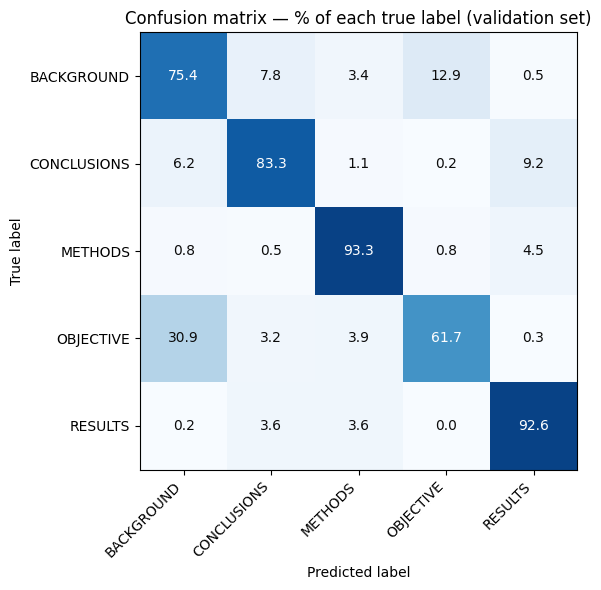

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

val_encodings = demo_tokenizer(list(X_val), truncation=True, padding=True, max_length=64, return_tensors="tf")
val_logits = demo_model.predict(dict(val_encodings), batch_size=64, verbose=0).logits
val_predictions = tf.argmax(val_logits, axis=1).numpy()

print(classification_report(y_val, val_predictions, target_names=label_classes, digits=3))

cm = confusion_matrix(y_val, val_predictions, normalize="true") * 100

fig, ax = plt.subplots(figsize=(6.5, 6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(label_classes)))
ax.set_yticks(range(len(label_classes)))
ax.set_xticklabels(label_classes, rotation=45, ha="right")
ax.set_yticklabels(label_classes)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix — % of each true label (validation set)")
for i in range(len(label_classes)):
    for j in range(len(label_classes)):
        color = "white" if cm[i, j] > 55 else "#0b0b0b"
        ax.text(j, i, f"{cm[i, j]:.1f}", ha="center", va="center", color=color, fontsize=10)
plt.tight_layout()
plt.show()

Methods and Results are still the strongest categories, both over 90% on precision and recall. Objective was the clear weak point before — and the class weighting actually did its job: recall jumped from 53.7% to 61.7%, and the dominant failure mode, Objective getting predicted as Background, dropped from 39% of the time down to 30.9%. It's not free, though — Background now gets called Objective more often than it used to (12.9% vs 7.8% before), so the model is trading a bit of Background's accuracy for Objective's. Overall accuracy dipped slightly, from 87.5% to 87.1%, but the balance across categories is genuinely better than it was, which is the thing we actually set out to fix.

Let's actually look at a few of these mistakes directly, instead of just staring at percentages.

In [22]:
val_df_reset = val_df.reset_index(drop=True)
wrong_mask = val_predictions != y_val
wrong_examples = val_df_reset[wrong_mask].copy()
wrong_examples["predicted"] = [label_classes[p] for p in val_predictions[wrong_mask]]

print(f"Misclassified: {wrong_mask.sum()} / {len(y_val)} ({wrong_mask.sum() / len(y_val) * 100:.2f}%)\n")

sample = wrong_examples.sample(6, random_state=42)
for _, row in sample.iterrows():
    print(f"True: {row['label']:<12} Predicted: {row['predicted']:<12} | {row['text']}")

Misclassified: 3915 / 30212 (12.96%)

True: BACKGROUND   Predicted: OBJECTIVE    | We investigated preferences for diagnostic testing for colorectal , lung , and pancreatic cancers in primary-care attendees .
True: OBJECTIVE    Predicted: BACKGROUND   | Data comparing the efficacy and safety of combination therapy with peginterferon plus low-dose ribavirin and peginterferon monotherapy in treatment-naive haemodialysis patients with hepatitis C virus genotype 2 ( HCV-2 ) infection are limited .
True: CONCLUSIONS  Predicted: BACKGROUND   | Exclusive breastfeeding is a cost-effective public health measure that has a significant impact on infant morbidity and mortality .
True: OBJECTIVE    Predicted: BACKGROUND   | Excessive menstrual bleeding , the most common complication caused by intrauterine devices ( IUDs ) , often leads to discontinuation of use .
True: OBJECTIVE    Predicted: BACKGROUND   | Instructional methods for the simple suture technique vary widely and are seldom based on ed

Yeah, that tracks with what the confusion matrix just showed. Look at the first one — "We investigated preferences for diagnostic testing for colorectal, lung, and pancreatic cancers in primary-care attendees." That's a Background sentence that got called Objective — and honestly, if I read that cold, I'd have guessed Objective too, since it literally starts with "We investigated." This is exactly the new failure mode from weighting Objective more heavily: sentences that sound like they're stating an aim, even when they're technically scene-setting, now lean Objective. A few of these aren't really model failures so much as genuinely ambiguous sentences sitting right on the boundary between two categories — which is a useful thing to know if this ever goes in front of a human reviewer.

Now for the real test. Here's a raw, unlabeled abstract — no section headers, nothing telling us where one part ends and the next begins, just one dense paragraph the way it'd actually show up if someone pasted it straight from a paper. Let's run it through and see if the model can figure out the structure on its own.

In [23]:
raw_abstract = (
    "Investigate the efficacy of several weeks of daily low-dose oral prednisolone in improving pain, "
    "mobility, and systemic low-grade inflammation in the short term, and whether the effect is sustained "
    "in older adults with moderate to severe knee osteoarthritis (OA). A total of a specified number of "
    "patients with primary knee OA were randomized into two groups; one group received a daily dose of "
    "prednisolone while the other received a placebo. Outcome measures included pain reduction, improvement "
    "in function scores, and systemic inflammation markers. Pain was assessed using the visual analog pain "
    "scale. Secondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis "
    "Index scores, patient global assessment of knee OA severity, and walk distance. Serum levels of various "
    "biomarkers were measured. There was a clinically relevant reduction in the intervention group compared "
    "to the placebo group for knee pain, physical function, and other measures at different time points."
)

print("BEFORE - raw, unstructured:\n")
print(raw_abstract)

pairs = segment_abstract(raw_abstract)

print("\n\nAFTER - automatically segmented:\n")
display(Markdown(format_segmented(pairs)))

BEFORE - raw, unstructured:

Investigate the efficacy of several weeks of daily low-dose oral prednisolone in improving pain, mobility, and systemic low-grade inflammation in the short term, and whether the effect is sustained in older adults with moderate to severe knee osteoarthritis (OA). A total of a specified number of patients with primary knee OA were randomized into two groups; one group received a daily dose of prednisolone while the other received a placebo. Outcome measures included pain reduction, improvement in function scores, and systemic inflammation markers. Pain was assessed using the visual analog pain scale. Secondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores, patient global assessment of knee OA severity, and walk distance. Serum levels of various biomarkers were measured. There was a clinically relevant reduction in the intervention group compared to the placebo group for knee pain, physical function, and o

**Objective:** Investigate the efficacy of several weeks of daily low-dose oral prednisolone in improving pain, mobility, and systemic low-grade inflammation in the short term, and whether the effect is sustained in older adults with moderate to severe knee osteoarthritis (OA).

**Methods:** A total of a specified number of patients with primary knee OA were randomized into two groups; one group received a daily dose of prednisolone while the other received a placebo. Outcome measures included pain reduction, improvement in function scores, and systemic inflammation markers. Pain was assessed using the visual analog pain scale. Secondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores, patient global assessment of knee OA severity, and walk distance. Serum levels of various biomarkers were measured.

**Results:** There was a clinically relevant reduction in the intervention group compared to the placebo group for knee pain, physical function, and other measures at different time points.

And there it is — one dense paragraph, automatically split into Objective, Methods, and Results, without me telling it anywhere where those boundaries were. That's the whole point of this project: turn something a person has to slog through line by line into something they can scan in five seconds.

That's the technical side wrapped up — next is turning this into something the business side can actually read.